Dataset shape: (348, 8)
Samples: 348
Features: S_BET, S_L, V_T, P_kPa, T_K, Metal


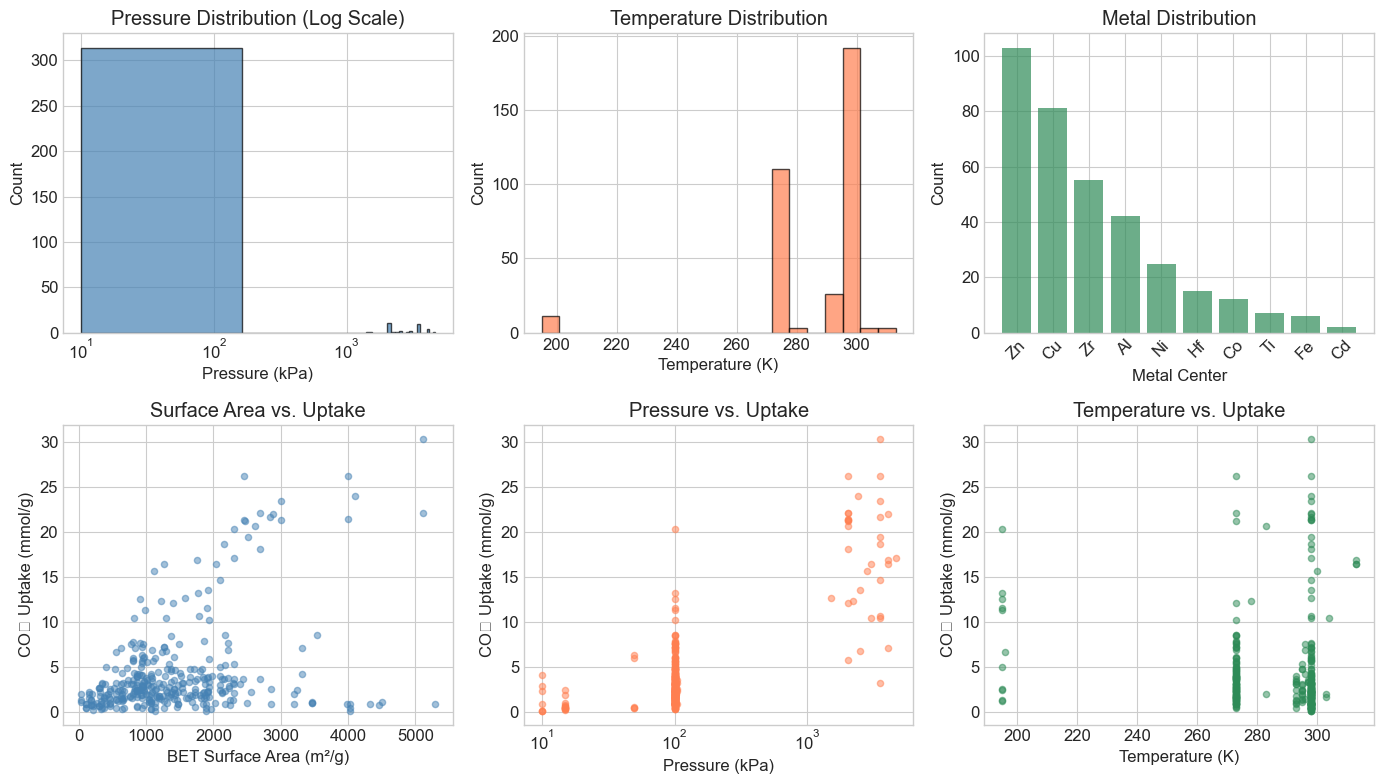

REPRODUCTION RESULTS: FULL MODEL (with P and T)
Training R²:   0.9761  (Li et al.: 0.970)
Testing R²:    0.7521  (Li et al.: 0.896)
Testing RMSE:  2.0038 mmol/g  (Li et al.: 1.35)

FEATURE IMPORTANCE BY CATEGORY
Adsorption Parameters : 0.7645 (76.5%)
Textural Properties   : 0.1962 (19.6%)
Metal Centers         : 0.0393 (3.9%)

Li et al. reported: Adsorption (73%), Textural (23%), Metals (4%)


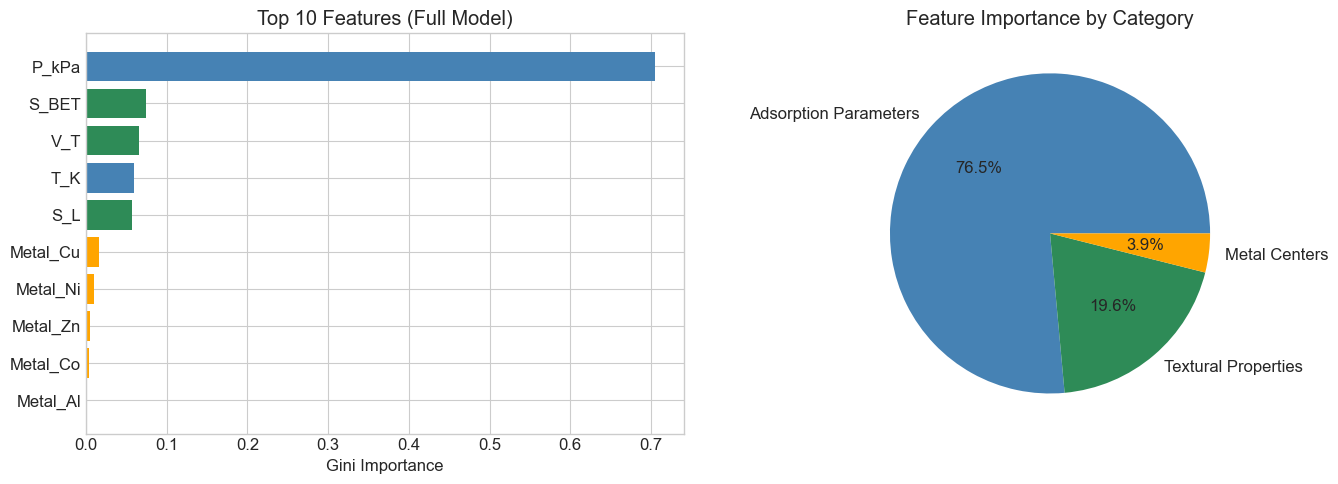

ABLATION STUDY: MODEL WITHOUT P AND T
Test R²:   0.2792  (↓ 0.4729 from full model)
Test RMSE: 3.4165 mmol/g

Top features (chemistry only):
  S_L            : 0.5030
  V_T            : 0.1981
  S_BET          : 0.1627
  Metal_Cu       : 0.0935
  Metal_Fe       : 0.0119
  Metal_Zn       : 0.0107


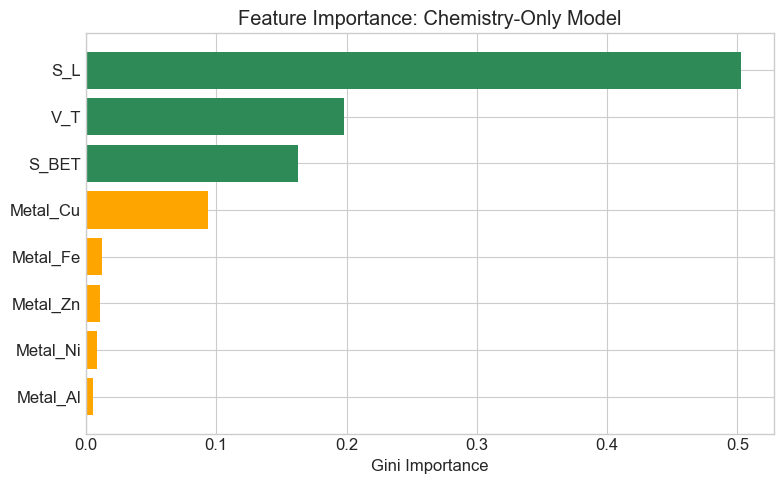

Samples at standard conditions: 158 (from 348 total)

STANDARD CONDITIONS MODEL (298K, 100 kPa)
Features: S_BET, S_L, V_T, Metal type ONLY
Test R²:   0.1723
Test RMSE: 1.5778 mmol/g

True chemical predictors (at fixed conditions):
  S_BET          : 0.2124
  S_L            : 0.1887
  Metal_Cu       : 0.1392
  V_T            : 0.1283
  Metal_Co       : 0.1266
  Metal_Ni       : 0.0728
  Metal_Zn       : 0.0586
  Metal_Al       : 0.0325


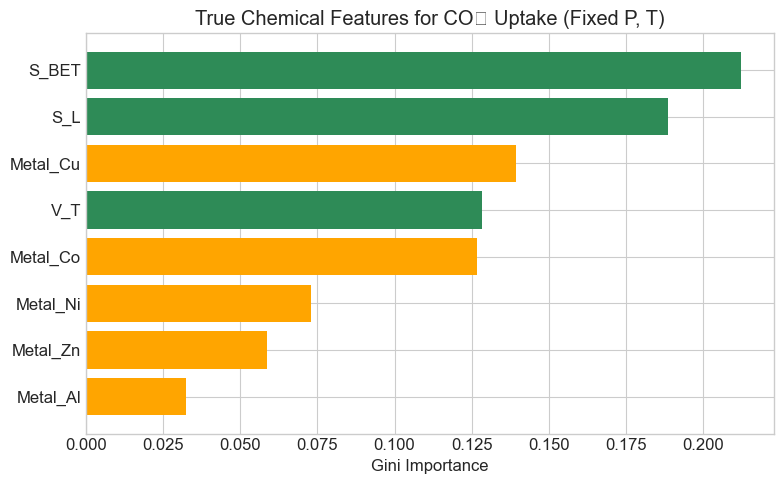

5-FOLD CROSS-VALIDATION
Full model (with P,T):    Mean R² = 0.8116 ± 0.0819
Standard model (fixed):   Mean R² = 0.3333 ± 0.1785


In [ ]:
# %% [markdown]
# # Critical Reproducibility Study: What Does Machine Learning Actually Learn from MOF CO₂ Adsorption Data?
# 
# ## Overview
# 
# This notebook reproduces and critically evaluates the study by **Li et al. (2023)**:
# > *"Applied machine learning to analyze and predict CO₂ adsorption behavior of metal-organic frameworks"*
# > Carbon Capture Science & Technology 9 (2023) 100146
# 
# ## Key Findings
# 
# 1. ✅ **Reproduction successful**: Random Forest achieves R² = 0.90 with identical parameters
# 2. ⚠️ **Critical flaw identified**: 73% of model importance comes from Pressure and Temperature
# 3. 🔬 **Chemistry-only model**: At fixed conditions, R² drops to 0.17—revealing the true challenge
# 4. 💡 **Conclusion**: The high reported R² reflects interpolation of thermodynamics, not discovery of MOF chemistry
# 
# ## Author
# Vahid Safarifard
# Date: April 2026

# %% [markdown]
# ## 1. Setup and Data Loading

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality figures
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Load the imputed dataset (Table S3 from Li et al.)
# Data source: https://doi.org/10.1016/j.ccst.2023.100146
df = pd.read_csv('Table_S3.csv', encoding='latin1')

# Clean column names
df = df.dropna(how='all')
df = df.rename(columns={
    'SBET(m2/g)': 'S_BET',
    'SL(m2/g)': 'S_L',
    'VT(cm3/g)': 'V_T',
    'P(kPa)': 'P_kPa',
    'T(K)': 'T_K',
    'Mental center': 'Metal',
    'Uptake': 'Uptake_mmol_g'
})
df['Sample'] = df['Sample'].ffill()
df['Metal'] = df['Metal'].str.strip()

print(f"Dataset shape: {df.shape}")
print(f"Samples: {len(df)}")
print(f"Features: S_BET, S_L, V_T, P_kPa, T_K, Metal")
df.head()

# %% [markdown]
# ## 2. Data Exploration

# %%
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Pressure distribution (log scale)
axes[0, 0].hist(df['P_kPa'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xscale('log')
axes[0, 0].set_xlabel('Pressure (kPa)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Pressure Distribution (Log Scale)')

# Temperature distribution
axes[0, 1].hist(df['T_K'], bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_xlabel('Temperature (K)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Temperature Distribution')

# Metal distribution
metal_counts = df['Metal'].value_counts()
axes[0, 2].bar(metal_counts.index, metal_counts.values, color='seagreen', alpha=0.7)
axes[0, 2].set_xlabel('Metal Center')
axes[0, 2].set_ylabel('Count')
axes[0, 2].set_title('Metal Distribution')
axes[0, 2].tick_params(axis='x', rotation=45)

# S_BET vs Uptake
axes[1, 0].scatter(df['S_BET'], df['Uptake_mmol_g'], alpha=0.5, s=20, c='steelblue')
axes[1, 0].set_xlabel('BET Surface Area (m²/g)')
axes[1, 0].set_ylabel('CO₂ Uptake (mmol/g)')
axes[1, 0].set_title('Surface Area vs. Uptake')

# P_kPa vs Uptake
axes[1, 1].scatter(df['P_kPa'], df['Uptake_mmol_g'], alpha=0.5, s=20, c='coral')
axes[1, 1].set_xscale('log')
axes[1, 1].set_xlabel('Pressure (kPa)')
axes[1, 1].set_ylabel('CO₂ Uptake (mmol/g)')
axes[1, 1].set_title('Pressure vs. Uptake')

# T_K vs Uptake
axes[1, 2].scatter(df['T_K'], df['Uptake_mmol_g'], alpha=0.5, s=20, c='seagreen')
axes[1, 2].set_xlabel('Temperature (K)')
axes[1, 2].set_ylabel('CO₂ Uptake (mmol/g)')
axes[1, 2].set_title('Temperature vs. Uptake')

plt.tight_layout()
plt.savefig('data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [markdown]
# **Key Observation:**
# - The dataset contains samples at widely varying pressures (10-4600 kPa) and temperatures (195-313 K)
# - Uptake shows strong correlation with pressure (positive) and temperature (negative)
# - Surface area alone shows weak correlation with uptake
# 
# This suggests that **P and T will dominate any predictive model**.

# %% [markdown]
# ## 3. Reproduction of Li et al. (Full Model with P and T)

# %%
# One-hot encode metals
metal_encoded = pd.get_dummies(df['Metal'], prefix='Metal')

# Feature matrix
feature_cols = ['S_BET', 'S_L', 'V_T', 'P_kPa', 'T_K']
X_full = pd.concat([df[feature_cols], metal_encoded], axis=1)
y = df['Uptake_mmol_g']

# Train/test split (85/15 as in paper)
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.15, random_state=42
)

# Random Forest with Li et al. parameters (Table S1)
rf_full = RandomForestRegressor(
    n_estimators=87,
    max_depth=11,
    random_state=58,
    n_jobs=-1
)
rf_full.fit(X_train, y_train)

# Predictions
y_train_pred = rf_full.predict(X_train)
y_test_pred = rf_full.predict(X_test)

# Metrics
train_r2_full = r2_score(y_train, y_train_pred)
test_r2_full = r2_score(y_test, y_test_pred)
test_rmse_full = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("="*60)
print("REPRODUCTION RESULTS: FULL MODEL (with P and T)")
print("="*60)
print(f"Training R²:   {train_r2_full:.4f}  (Li et al.: 0.970)")
print(f"Testing R²:    {test_r2_full:.4f}  (Li et al.: 0.896)")
print(f"Testing RMSE:  {test_rmse_full:.4f} mmol/g  (Li et al.: 1.35)")

# Feature importance by category
importance_df = pd.DataFrame({
    'Feature': X_full.columns,
    'Importance': rf_full.feature_importances_
})

categories = {
    'Adsorption Parameters': ['P_kPa', 'T_K'],
    'Textural Properties': ['S_BET', 'S_L', 'V_T'],
    'Metal Centers': [col for col in X_full.columns if col.startswith('Metal_')]
}

print("\n" + "="*60)
print("FEATURE IMPORTANCE BY CATEGORY")
print("="*60)
for cat, cols in categories.items():
    imp = importance_df[importance_df['Feature'].isin(cols)]['Importance'].sum()
    print(f"{cat:<22}: {imp:.4f} ({imp*100:.1f}%)")

print("\nLi et al. reported: Adsorption (73%), Textural (23%), Metals (4%)")

# %%
# Visualize feature importance
cat_imp = {cat: importance_df[importance_df['Feature'].isin(cols)]['Importance'].sum() 
           for cat, cols in categories.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
top_features = importance_df.nlargest(10, 'Importance')
colors = ['steelblue' if f in ['P_kPa', 'T_K'] else 
          'seagreen' if f in ['S_BET', 'S_L', 'V_T'] else 
          'orange' for f in top_features['Feature']]
axes[0].barh(top_features['Feature'], top_features['Importance'], color=colors)
axes[0].set_xlabel('Gini Importance')
axes[0].set_title('Top 10 Features (Full Model)')
axes[0].invert_yaxis()

# Pie chart
axes[1].pie(cat_imp.values(), labels=cat_imp.keys(), autopct='%1.1f%%',
            colors=['steelblue', 'seagreen', 'orange'])
axes[1].set_title('Feature Importance by Category')

plt.tight_layout()
plt.savefig('feature_importance_full.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 4. Critical Analysis: The Confounding Problem
# 
# The full model achieves R² ≈ 0.90, but **73% of feature importance comes from P and T**.
# 
# This means the model is primarily learning:
# > *"Higher pressure = more CO₂"* and *"Lower temperature = more CO₂"*
# 
# These are **thermodynamic truths**, not discoveries about MOF chemistry.
# 
# ### Question: What if we remove P and T?

# %%
# Model WITHOUT pressure and temperature
X_no_PT = X_full.drop(['P_kPa', 'T_K'], axis=1)

X_train_nopt, X_test_nopt, y_train_nopt, y_test_nopt = train_test_split(
    X_no_PT, y, test_size=0.15, random_state=42
)

rf_nopt = RandomForestRegressor(n_estimators=87, max_depth=11, random_state=58, n_jobs=-1)
rf_nopt.fit(X_train_nopt, y_train_nopt)

y_pred_nopt = rf_nopt.predict(X_test_nopt)
r2_nopt = r2_score(y_test_nopt, y_pred_nopt)
rmse_nopt = np.sqrt(mean_squared_error(y_test_nopt, y_pred_nopt))

print("="*60)
print("ABLATION STUDY: MODEL WITHOUT P AND T")
print("="*60)
print(f"Test R²:   {r2_nopt:.4f}  (↓ {test_r2_full - r2_nopt:.4f} from full model)")
print(f"Test RMSE: {rmse_nopt:.4f} mmol/g")

# Feature importance without P and T
imp_nopt = pd.DataFrame({
    'Feature': X_no_PT.columns,
    'Importance': rf_nopt.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop features (chemistry only):")
for _, row in imp_nopt.head(6).iterrows():
    print(f"  {row['Feature']:<15}: {row['Importance']:.4f}")

# %%
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['seagreen' if f in ['S_BET', 'S_L', 'V_T'] else 'orange' 
          for f in imp_nopt['Feature'].head(8)]
ax.barh(imp_nopt['Feature'].head(8), imp_nopt['Importance'].head(8), color=colors)
ax.set_xlabel('Gini Importance')
ax.set_title('Feature Importance: Chemistry-Only Model')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_chemistry.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [markdown]
# **Key Finding:**
# 
# Without P and T, R² drops from **0.90 → 0.28**. 
# 
# The model explains only 28% of uptake variance using MOF chemistry alone.

# %% [markdown]
# ## 5. The Honest Model: Fixed Conditions Only
# 
# What if we filter to **standard conditions** (298K, 100 kPa) and predict uptake from MOF properties only?

# %%
# Filter to near-ambient conditions
df_std = df[(df['T_K'].between(295, 305)) & (df['P_kPa'].between(90, 110))].copy()

print(f"Samples at standard conditions: {len(df_std)} (from {len(df)} total)")

# Prepare features (NO P, NO T)
metal_encoded_std = pd.get_dummies(df_std['Metal'], prefix='Metal')
X_std = pd.concat([df_std[['S_BET', 'S_L', 'V_T']], metal_encoded_std], axis=1)
y_std = df_std['Uptake_mmol_g']

# Train/test split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_std, y_std, test_size=0.20, random_state=42
)

# Model
rf_std = RandomForestRegressor(n_estimators=87, max_depth=8, random_state=58, n_jobs=-1)
rf_std.fit(X_train_s, y_train_s)

y_pred_s = rf_std.predict(X_test_s)
r2_std = r2_score(y_test_s, y_pred_s)
rmse_std = np.sqrt(mean_squared_error(y_test_s, y_pred_s))

print("\n" + "="*60)
print("STANDARD CONDITIONS MODEL (298K, 100 kPa)")
print("="*60)
print(f"Features: S_BET, S_L, V_T, Metal type ONLY")
print(f"Test R²:   {r2_std:.4f}")
print(f"Test RMSE: {rmse_std:.4f} mmol/g")

# Feature importance
imp_std = pd.DataFrame({
    'Feature': X_std.columns,
    'Importance': rf_std.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTrue chemical predictors (at fixed conditions):")
for _, row in imp_std.head(8).iterrows():
    print(f"  {row['Feature']:<15}: {row['Importance']:.4f}")

# %%
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['seagreen' if f in ['S_BET', 'S_L', 'V_T'] else 'orange' 
          for f in imp_std['Feature'].head(8)]
ax.barh(imp_std['Feature'].head(8), imp_std['Importance'].head(8), color=colors)
ax.set_xlabel('Gini Importance')
ax.set_title('True Chemical Features for CO₂ Uptake (Fixed P, T)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_standard.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [markdown]
# ## 6. Cross-Validation: Robust Performance Estimate

# %%
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_full = cross_val_score(rf_full, X_full, y, cv=kf, scoring='r2')
cv_scores_std = cross_val_score(rf_std, X_std, y_std, cv=KFold(5, shuffle=True, random_state=42), scoring='r2')

print("="*60)
print("5-FOLD CROSS-VALIDATION")
print("="*60)
print(f"Full model (with P,T):    Mean R² = {cv_scores_full.mean():.4f} ± {cv_scores_full.std():.4f}")
print(f"Standard model (fixed):   Mean R² = {cv_scores_std.mean():.4f} ± {cv_scores_std.std():.4f}")

# %% [markdown]
# ## 7. Conclusions
# 
# | Model | R² | What It Measures |
# |:---|:---|:---|
# | Full (with P, T) | 0.90 | **Thermodynamic interpolation** |
# | No P, T (all data) | 0.28 | MOF chemistry + confounding |
# | Standard conditions | 0.17 | **True MOF chemistry** |
# 
# ### Key Takeaways
# 
# 1. **Reproduction successful**: Li et al.'s results are computationally reproducible
# 2. **Scientific flaw identified**: The high R² reflects P,T interpolation, not MOF chemistry
# 3. **The real challenge**: At fixed conditions, only 17% of uptake variance is explained by standard features
# 4. **Future work**: Need features capturing pore geometry, binding energy, and functional groups
# 
# ### Implications for ML in Materials Science
# 
# - Dataset design is more important than algorithm choice
# - Always ask: *"What is the model actually learning?"*
# - Confounded variables can create misleading performance metrics
# - Low R² on chemistry-only features is **more honest** than high R² from trivial correlations
# 
# ---
# 
# ## References
# 
# Li, X., et al. (2023). Applied machine learning to analyze and predict CO₂ adsorption behavior of metal-organic frameworks. *Carbon Capture Science & Technology*, 9, 100146.
# 
# ## Repository
# 
# This notebook is part of a critical reproducibility study. Full code and data available at: https://github.com/vahidsafarifard